In [1]:
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from arviz.labels import MapLabeller

from pymc_marketing import clv
from pymc_marketing.prior import Prior

az.style.use("arviz-darkgrid")

%config InlineBackend.figure_format = "retina" # nice looking plots

In [ ]:
raw_trans = pd.read_csv(
    "data/cdnow_transactions.csv"
)

raw_trans.head(5)

,_id,id,date,cds_bought,spent
0,4,1,19970101,2,29.33
1,4,1,19970118,2,29.73
2,4,1,19970802,1,14.96
3,4,1,19971212,2,26.48
4,21,2,19970101,3,63.34


In [21]:
rfm_data = clv.utils.rfm_summary(
    raw_trans,
    customer_id_col="id",
    datetime_col = "date",
    monetary_value_col = "spent",
    datetime_format="%Y%m%d",
    time_unit='W'
)
rfm_data

,customer_id,frequency,recency,T,monetary_value
0,1,3.0,49.0,78.0,23.723333
1,2,1.0,2.0,78.0,11.770000
2,3,0.0,0.0,78.0,0.000000
3,4,0.0,0.0,78.0,0.000000
4,5,0.0,0.0,78.0,0.000000
...,...,...,...,...,...
2352,2353,2.0,53.0,66.0,19.775000
2353,2354,5.0,24.0,66.0,44.928000
2354,2355,1.0,44.0,66.0,24.600000
2355,2356,6.0,62.0,66.0,31.871667


<AxesSubplot: title={'center': 'Customer Exposure'}, xlabel='Time since first purchase', ylabel='Customer'>

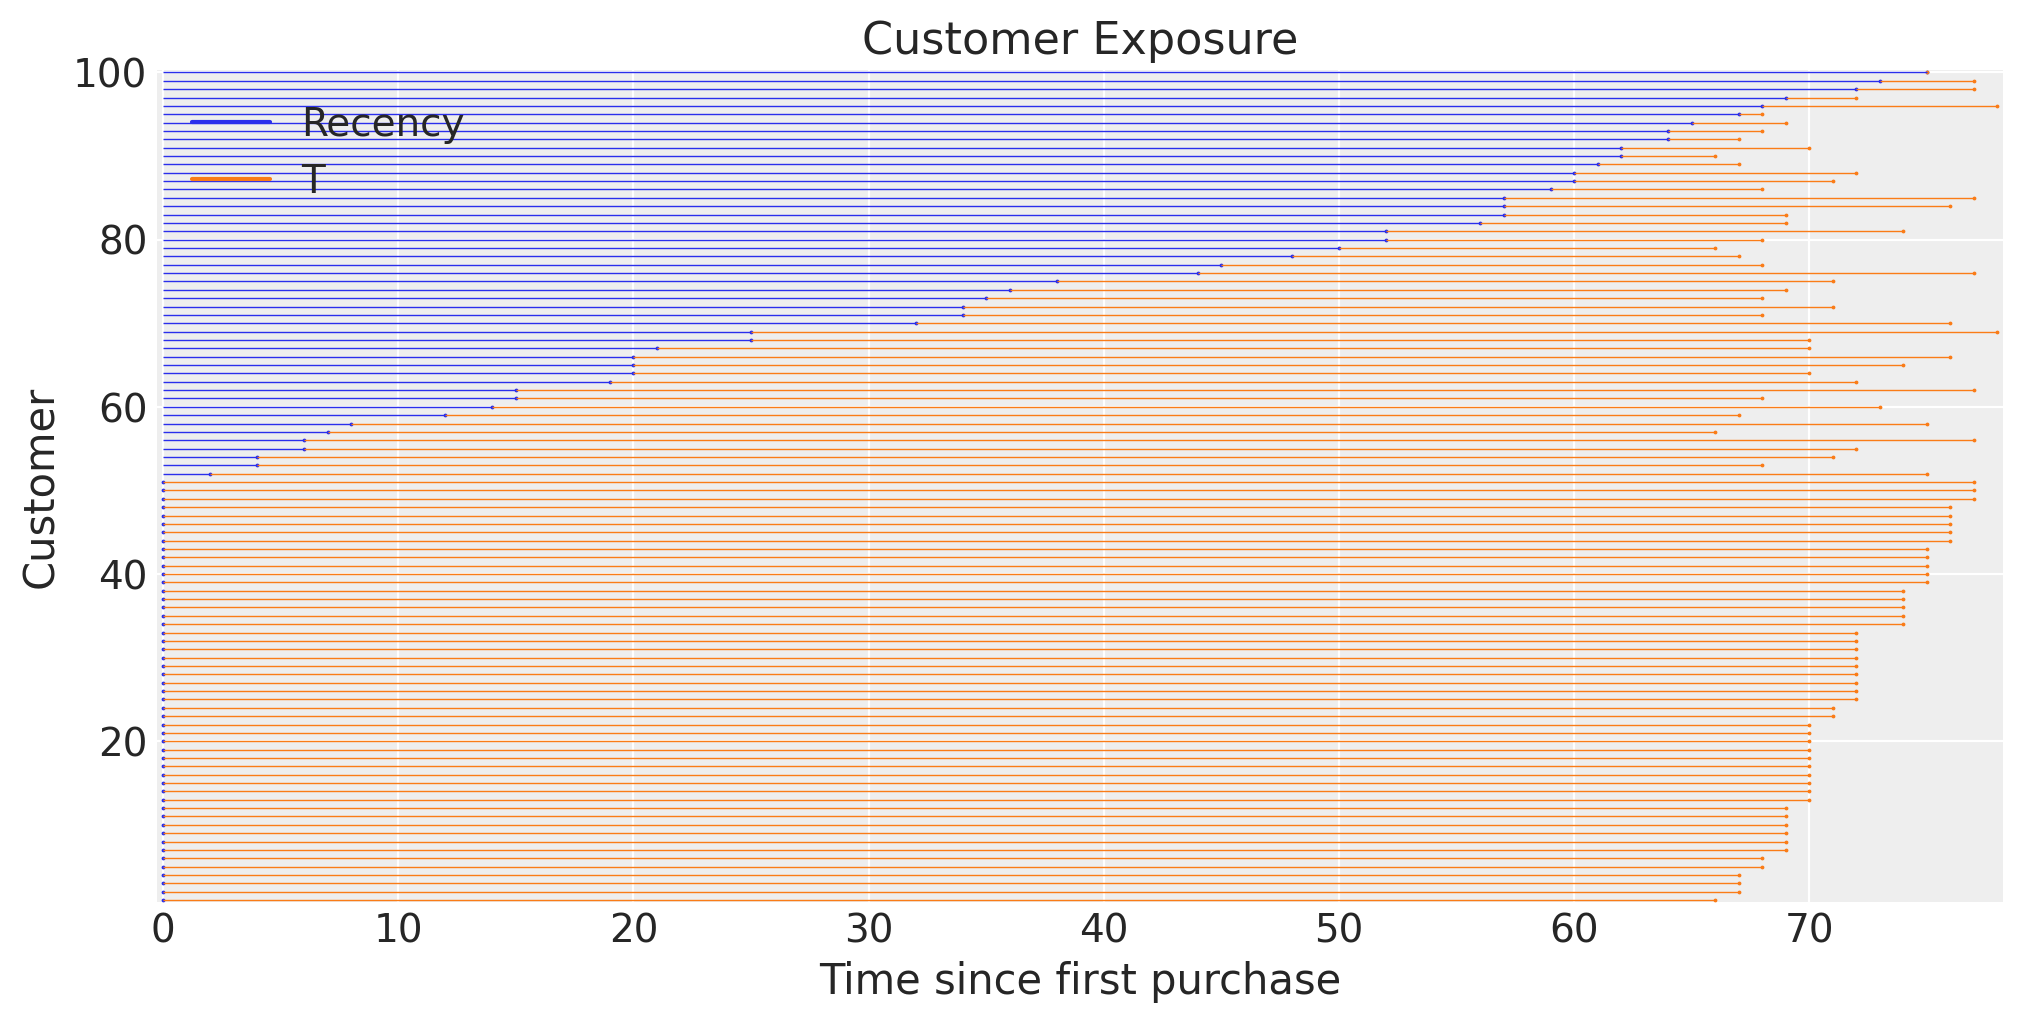

In [22]:
fig,ax = plt.subplots(figsize=(10,5))
(
    rfm_data.sample(n=100,random_state=42).sort_values(['recency',"T"]).pipe(clv.plot_customer_exposure,ax=ax,linewidth=0.5,size=0.75)
)

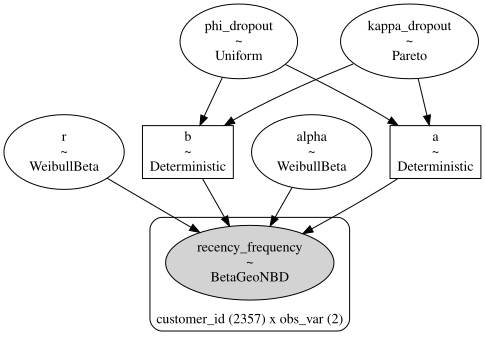

In [23]:
bgm = clv.BetaGeoModel(data=rfm_data)
bgm.build_model()
bgm.graphviz()

In [24]:
bgm.fit()
bgm.fit_summary()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi_dropout, kappa_dropout, r]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 34 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,7.130,0.494,6.230,8.076,0.010,0.008,2336.0,2549.0,1.0
phi_dropout,0.184,0.015,0.156,0.213,0.000,0.000,2320.0,2708.0,1.0
kappa_dropout,3.292,0.871,1.825,4.881,0.018,0.021,2429.0,2564.0,1.0
r,0.277,0.012,0.255,0.299,0.000,0.000,2332.0,2277.0,1.0
a,0.596,0.127,0.371,0.816,0.002,0.003,2997.0,3066.0,1.0
b,2.696,0.750,1.393,4.029,0.015,0.018,2364.0,2525.0,1.0


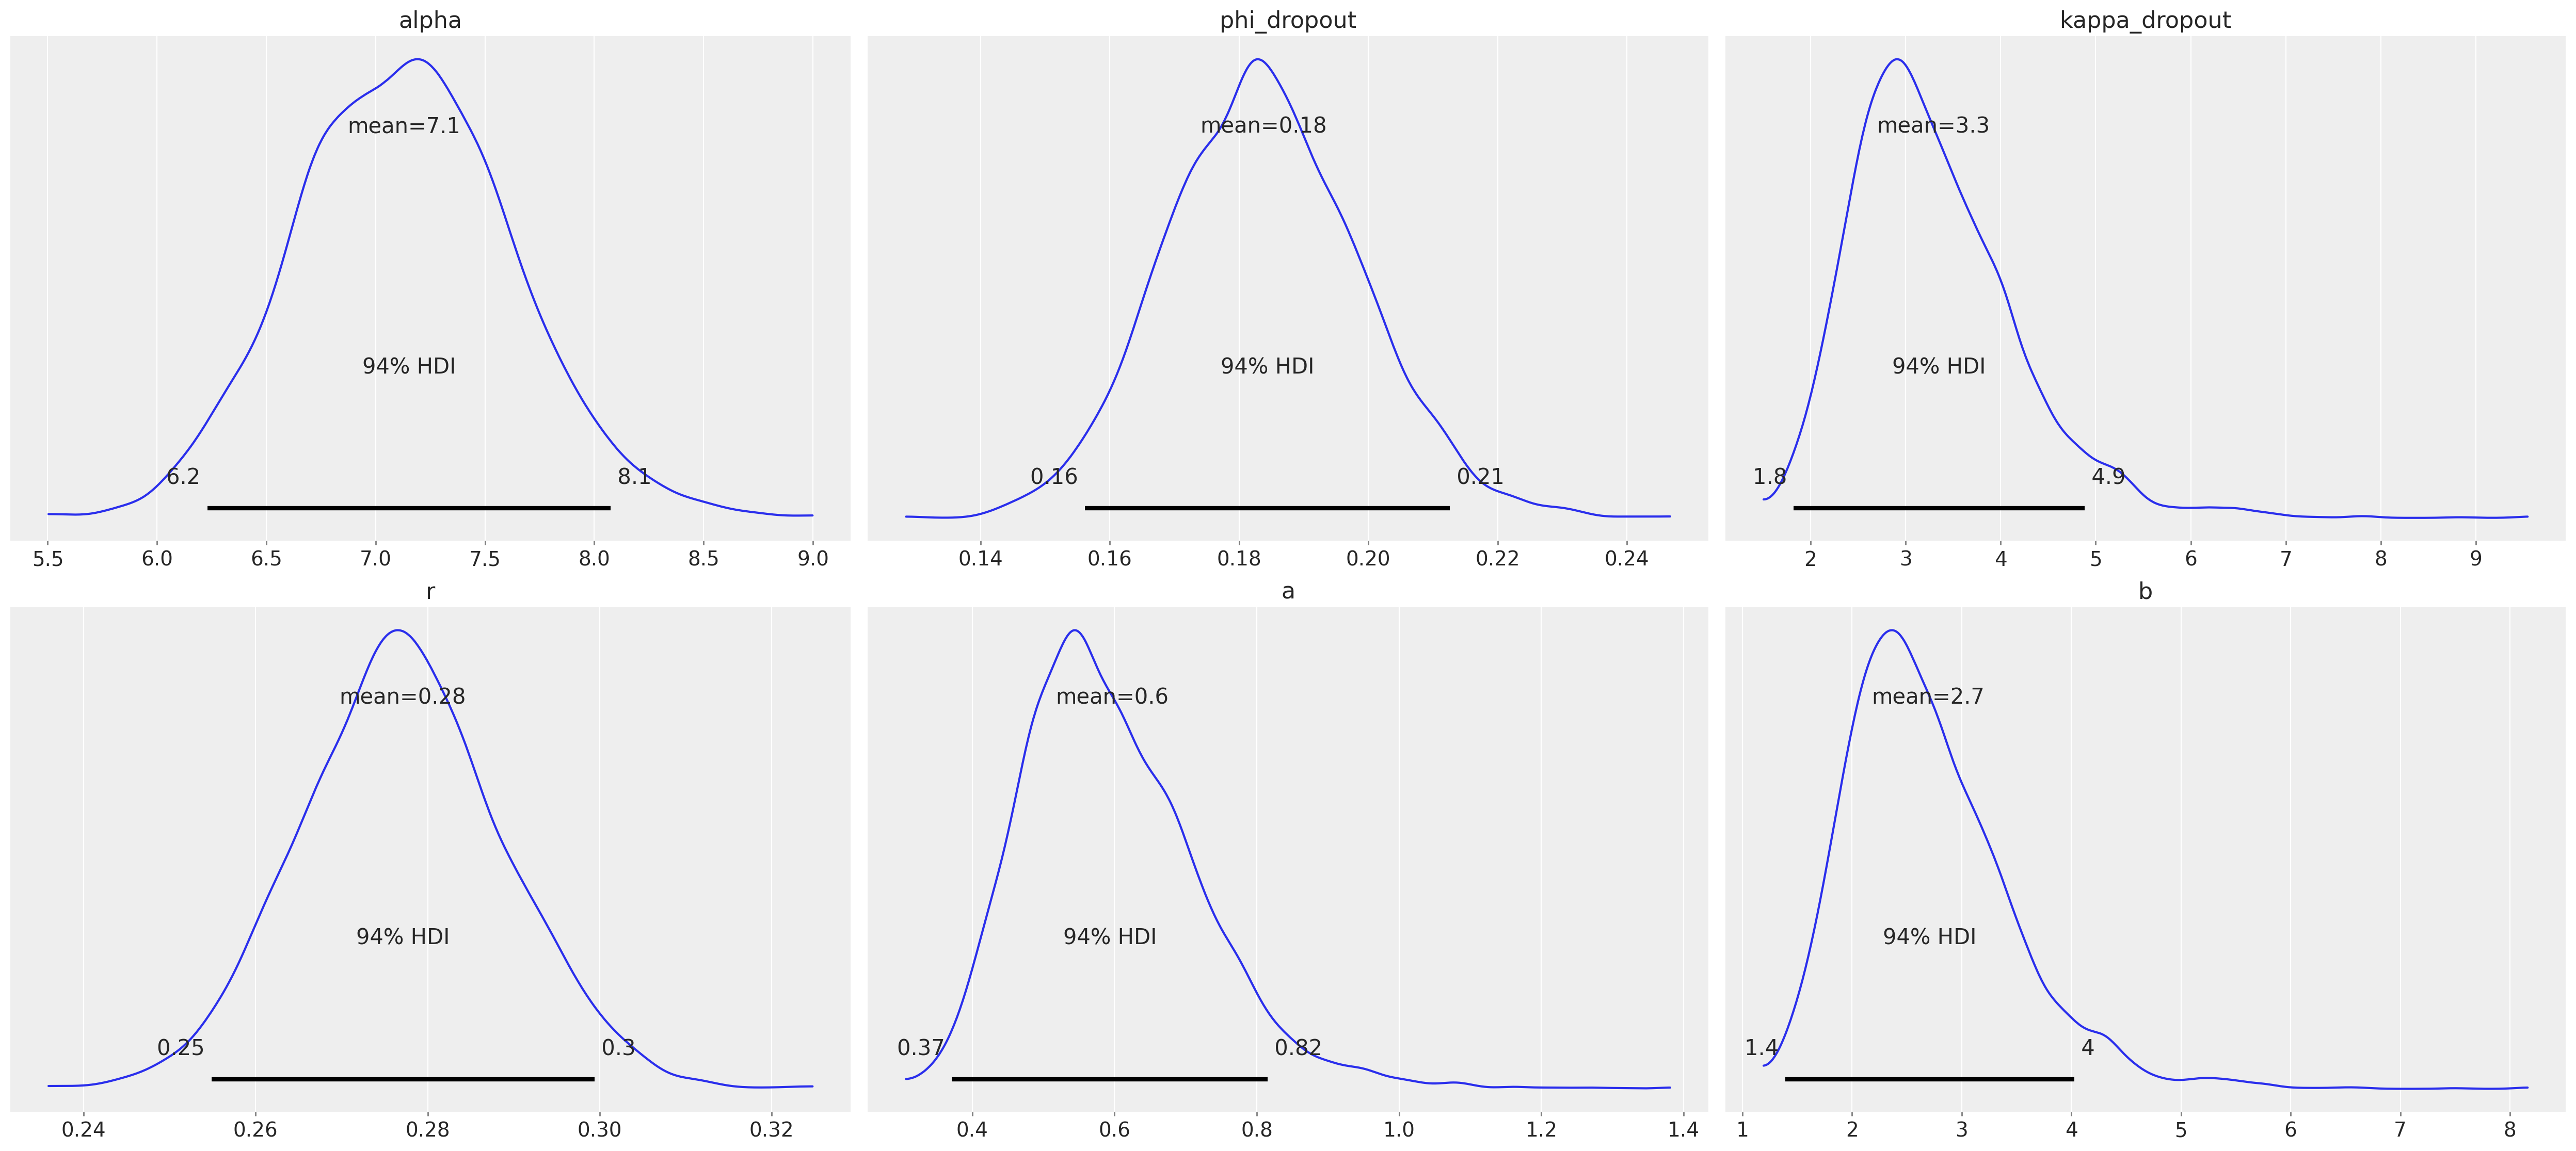

In [25]:
az.plot_posterior(bgm.fit_result);

<AxesSubplot: title={'center': 'Tracking Cumulative Transactions'}, xlabel='Time Periods', ylabel='Purchases'>

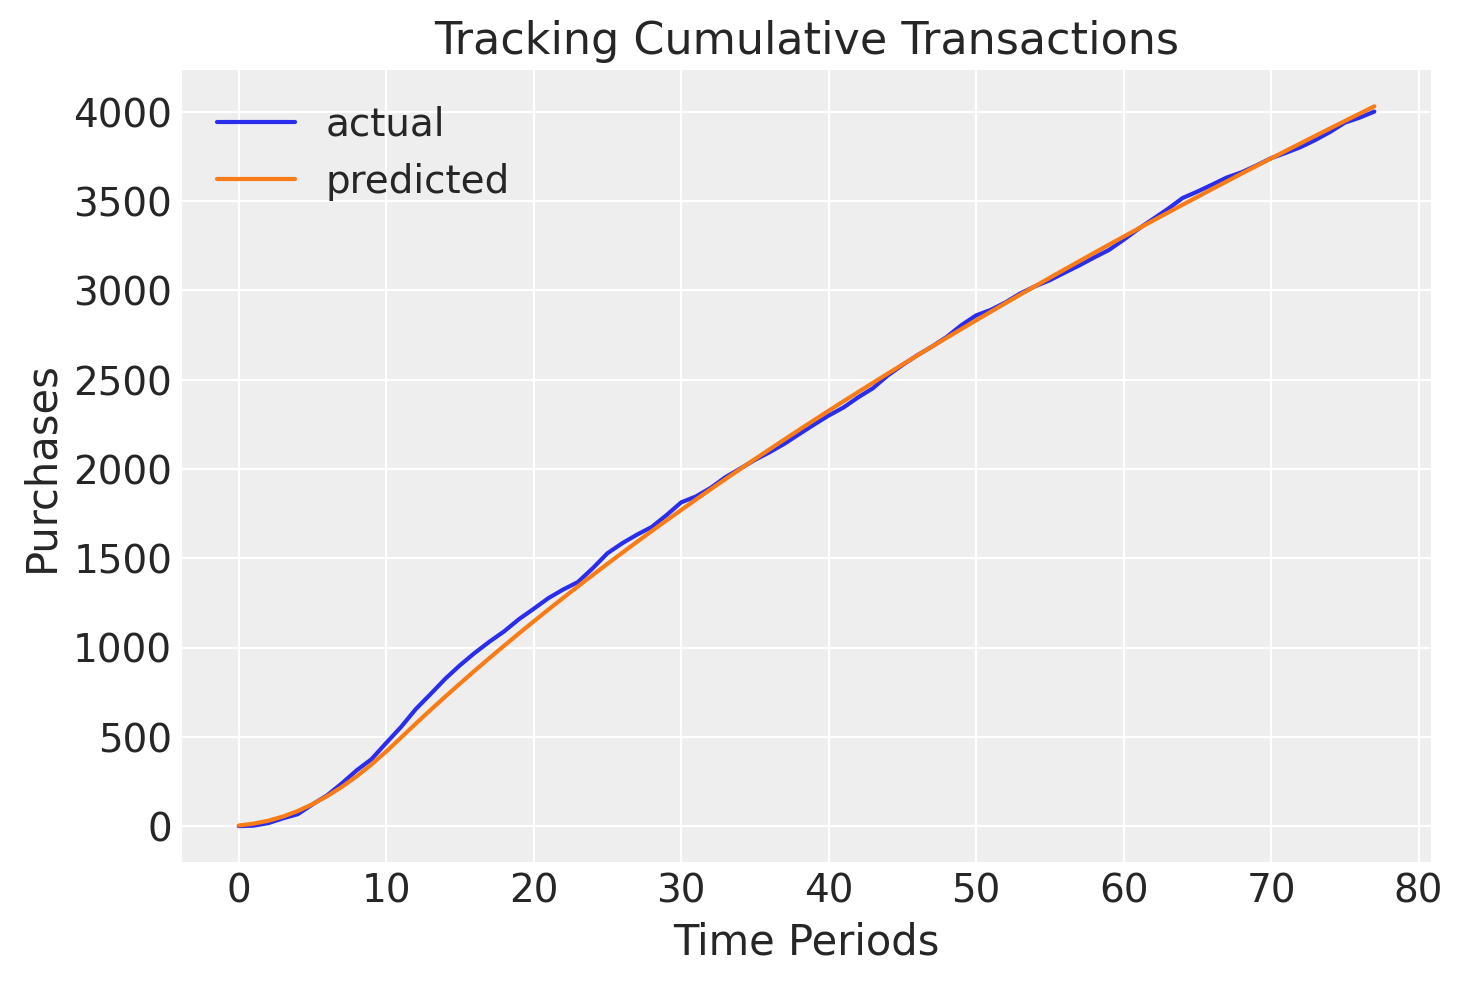

In [26]:
clv.plot_expected_purchases_over_time(model=bgm,
                                      purchase_history=raw_trans,
                                      datetime_col='date',
                                      customer_id_col='id',
                                      datetime_format="%Y%m%d",
                                      time_unit='W',
                                      t=78)

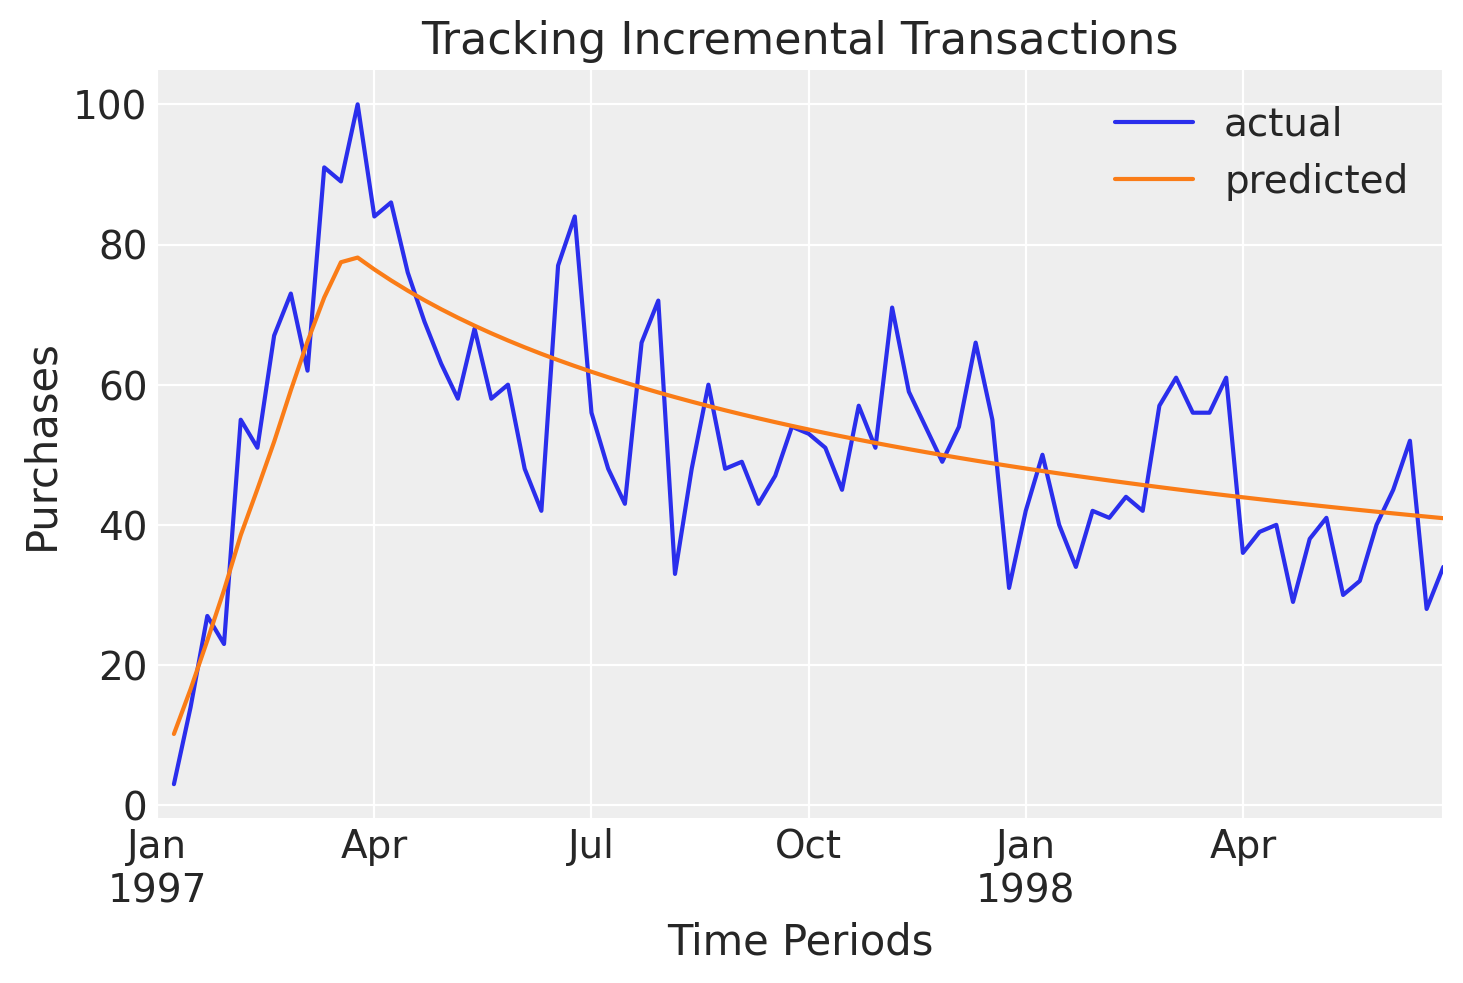

In [27]:
clv.plot_expected_purchases_over_time(
    model=bgm,
    purchase_history=raw_trans,
    datetime_col='date',
    customer_id_col='id',
    datetime_format="%Y%m%d",
    time_unit="W",
    t=78,
    plot_cumulative=False,
    set_index_date=True
);

<AxesSubplot: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

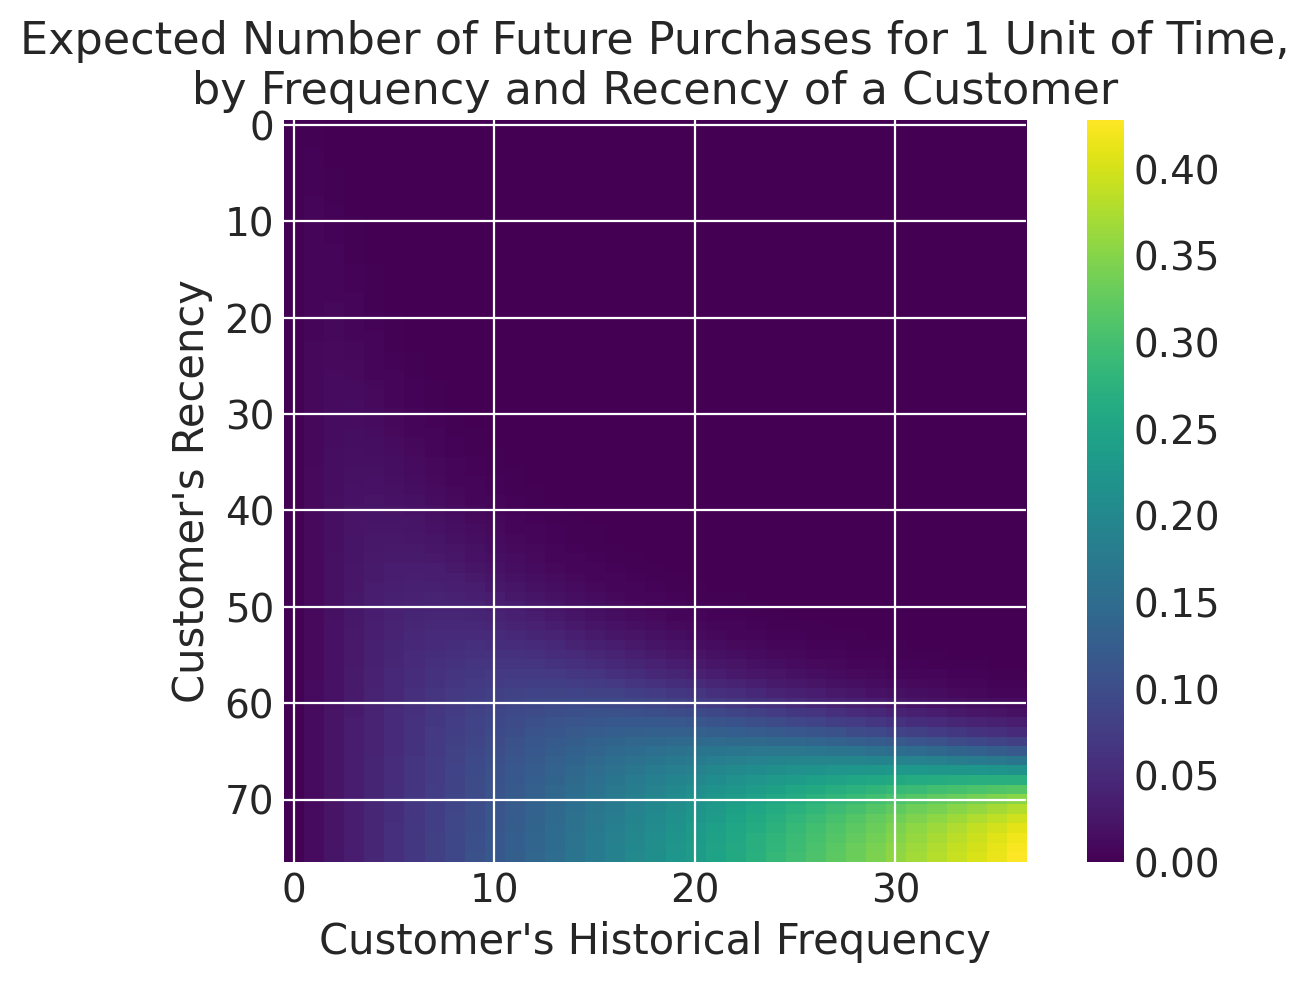

In [29]:
clv.plot_frequency_recency_matrix(bgm)

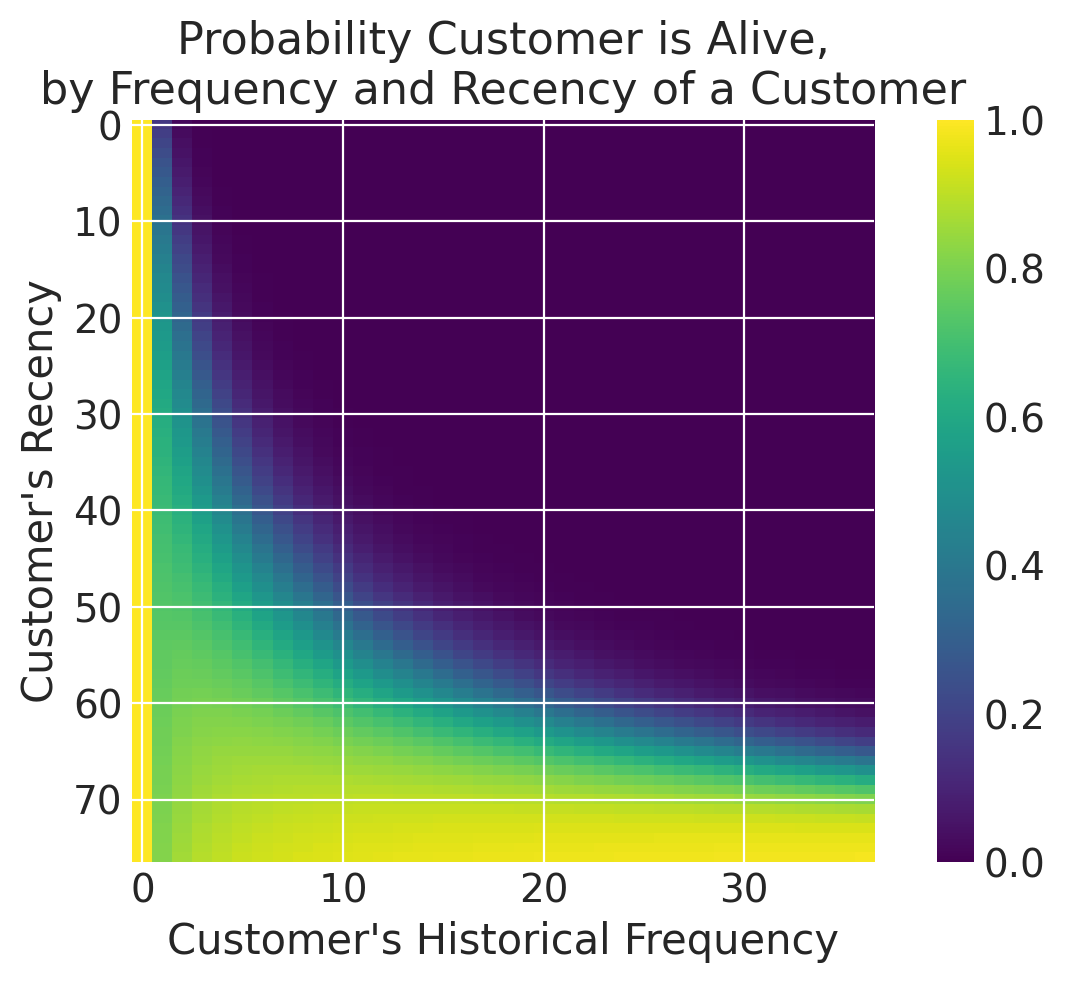

In [30]:
clv.plot_probability_alive_matrix(bgm);

In [39]:
num_purchases = bgm.expected_purchases(future_t=20)

sdata = rfm_data.copy()
sdata['expected_purchases'] = num_purchases.mean(("chain","draw")).values
sdata.sort_values(by='expected_purchases').tail(4)

,customer_id,frequency,recency,T,monetary_value,expected_purchases
812,813,30.0,72.0,74.0,35.654000,6.738711
1202,1203,32.0,71.0,72.0,47.172187,7.447905
156,157,36.0,74.0,77.0,30.603611,7.659010
1980,1981,35.0,66.0,68.0,46.748857,8.418317


Text(0.5, 0.98, 'Expected number purchases over 20 time units')

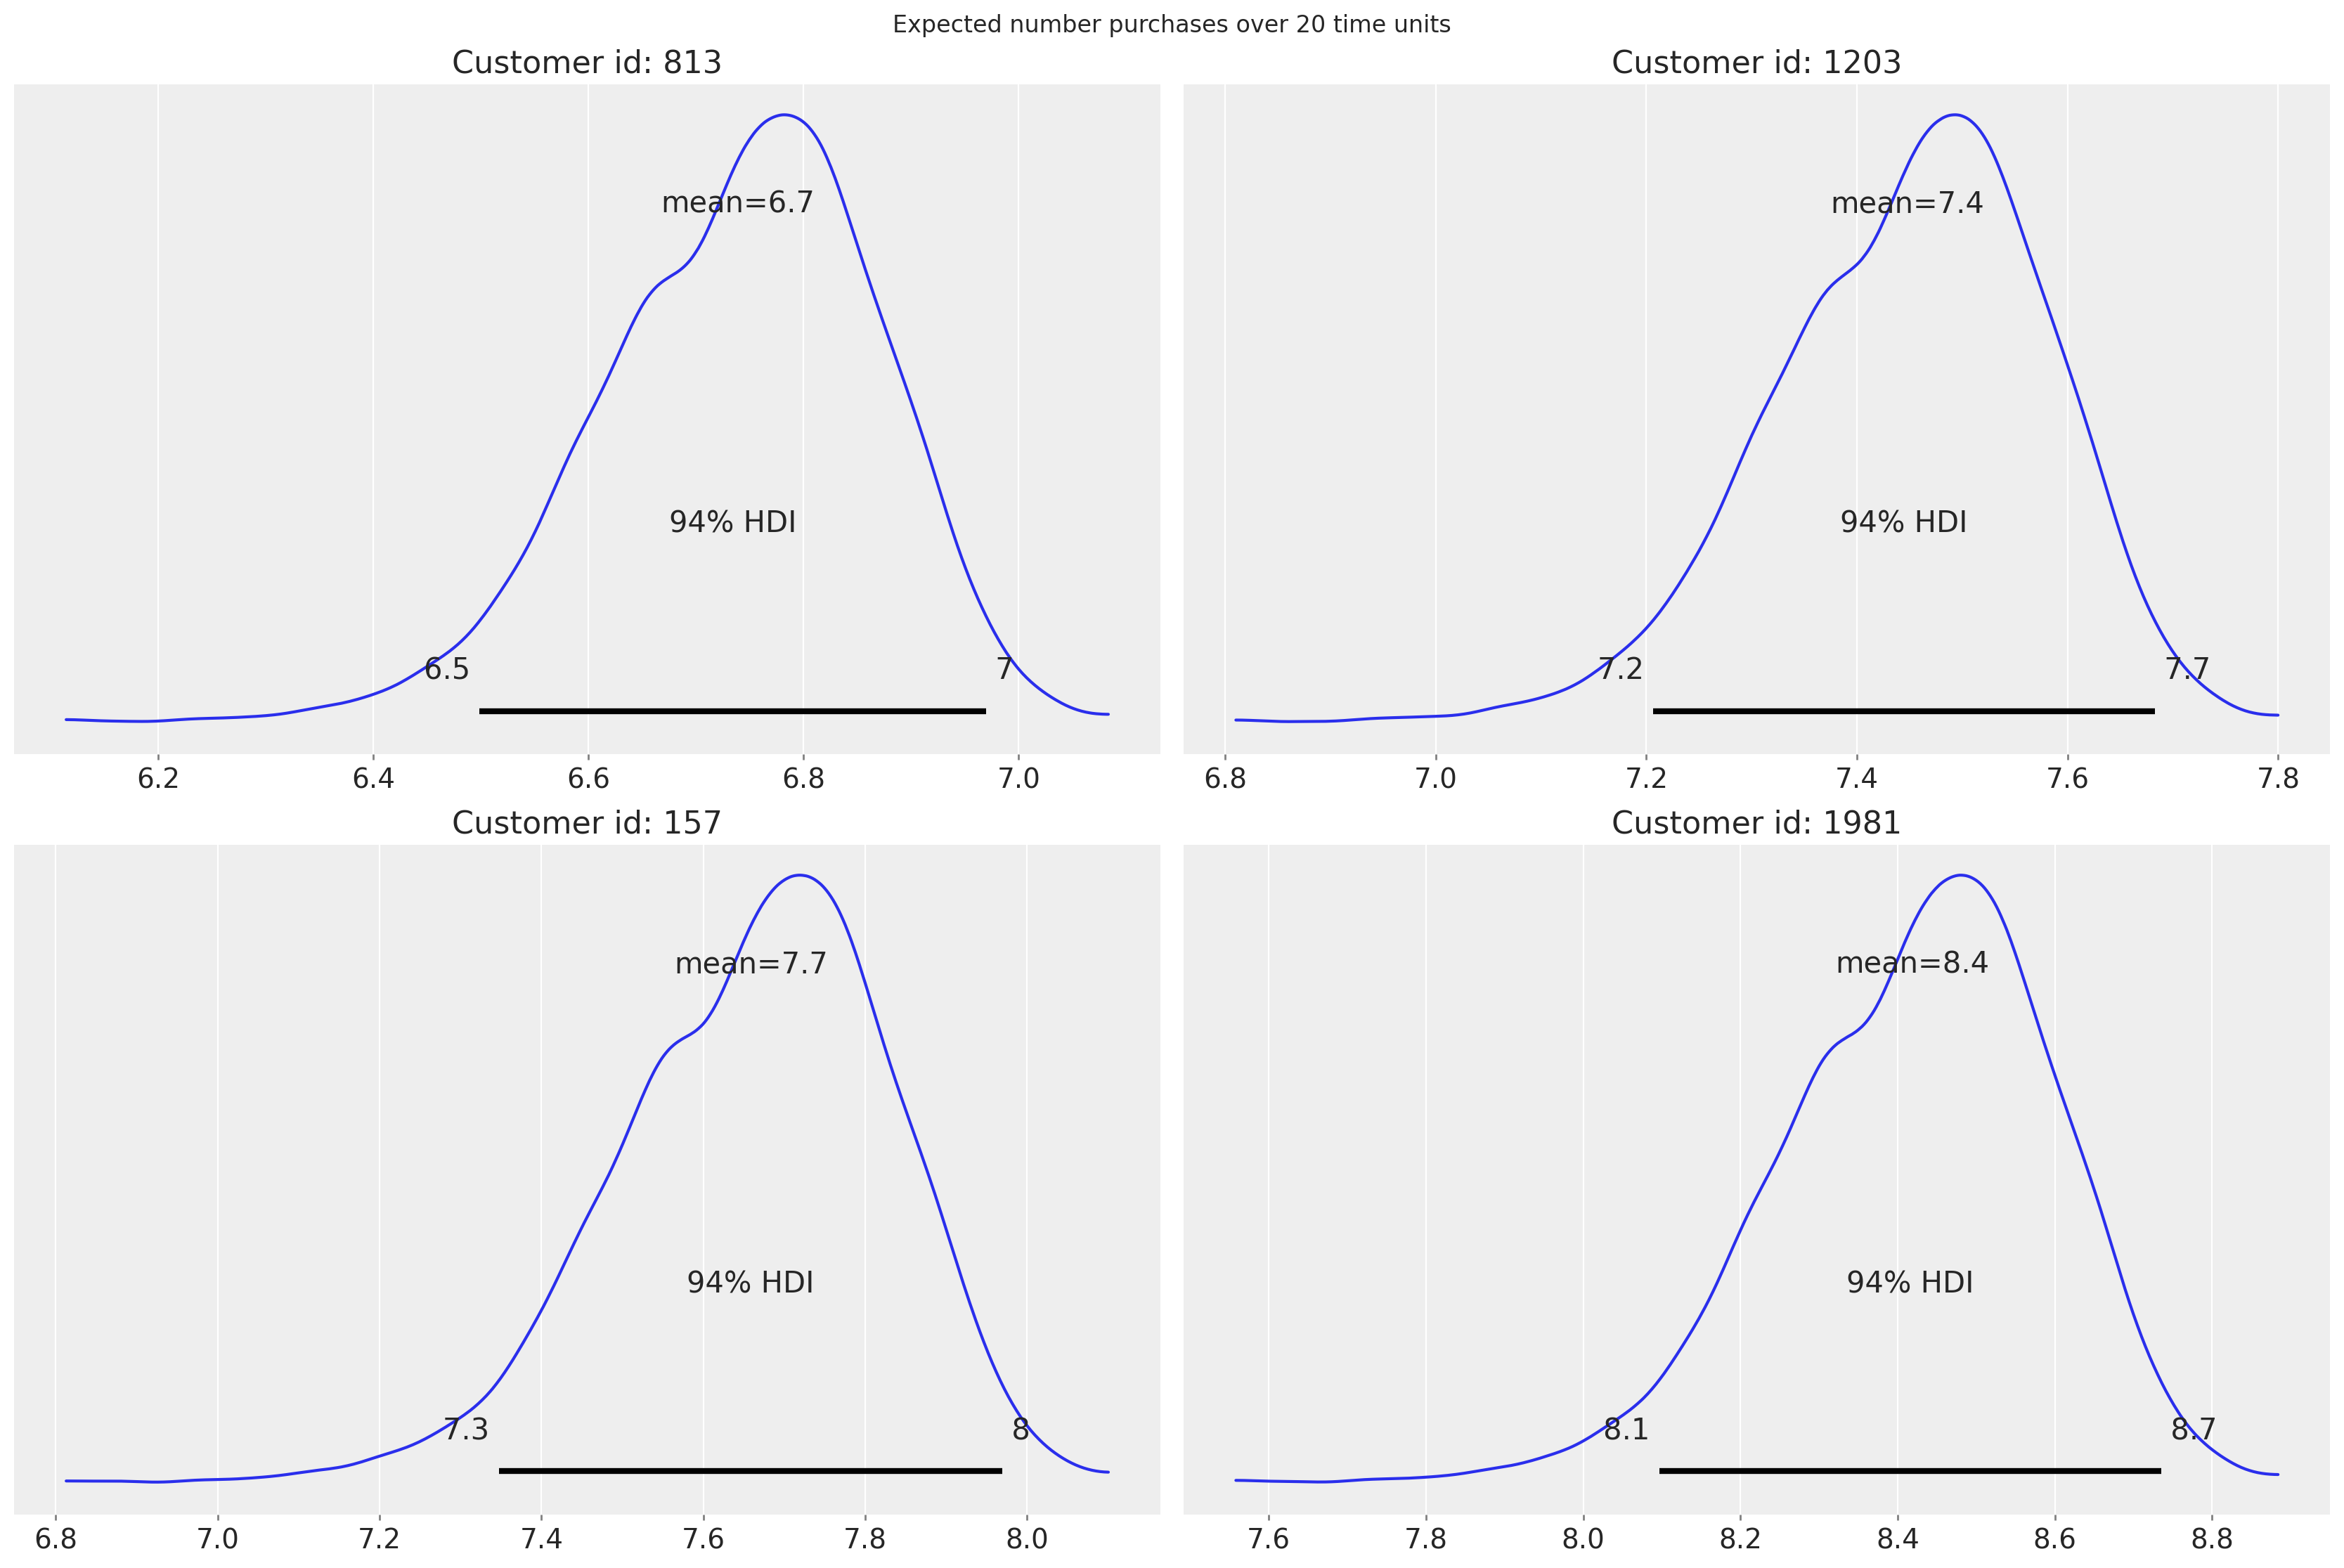

In [41]:
ids = sdata.sort_values(by='expected_purchases').tail(4)["customer_id"].values

ax = az.plot_posterior(num_purchases.sel(customer_id=ids),grid=(2,2))
for axs , id in zip(ax.ravel(),ids,strict=False):
    axs.set_title(f"Customer id: {id}")

plt.suptitle(f"Expected number purchases over 20 time units")

In [48]:
customer_1516 = rfm_data.loc[1515]
customer_1516_history = pd.DataFrame(dict(
    customer_id = np.arange(10),
    frequency = np.full(10,customer_1516["frequency"],dtype='int'),
    recency=np.full(10,customer_1516['recency']),
    T = (np.arange(0,10)+ customer_1516['recency']).astype("int")
))

p_alive = bgm.expected_probability_alive(data=customer_1516_history)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


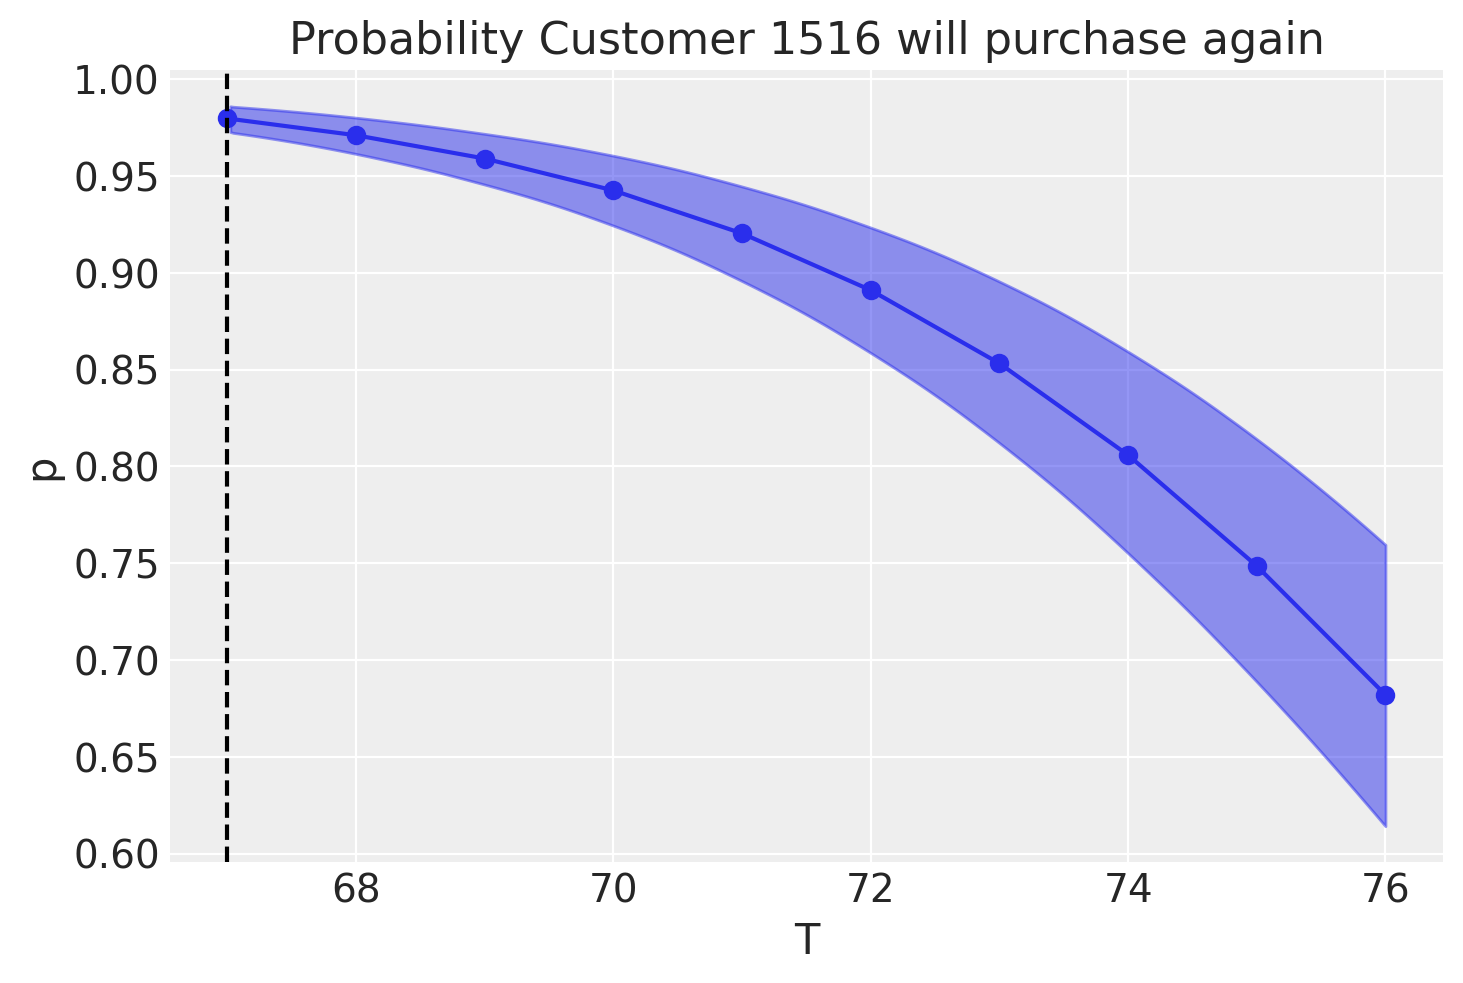

In [49]:
az.plot_hdi(customer_1516_history["T"],p_alive,color='C0')
plt.plot(customer_1516_history["T"],p_alive.mean(("chain","draw")),marker="o")
plt.axvline(customer_1516_history['recency'][0],ls="--",c='black')
plt.title("Probability Customer 1516 will purchase again")
plt.xlabel("T")
plt.ylabel("p")
plt.legend();

In [51]:
customer_1516_history.loc[7:, "frequency"] += 1
customer_1516_history.loc[7:, "recency"] = customer_1516_history.loc[7, "T"] - 0.5
p_alive = bgm.expected_probability_alive(customer_1516_history)

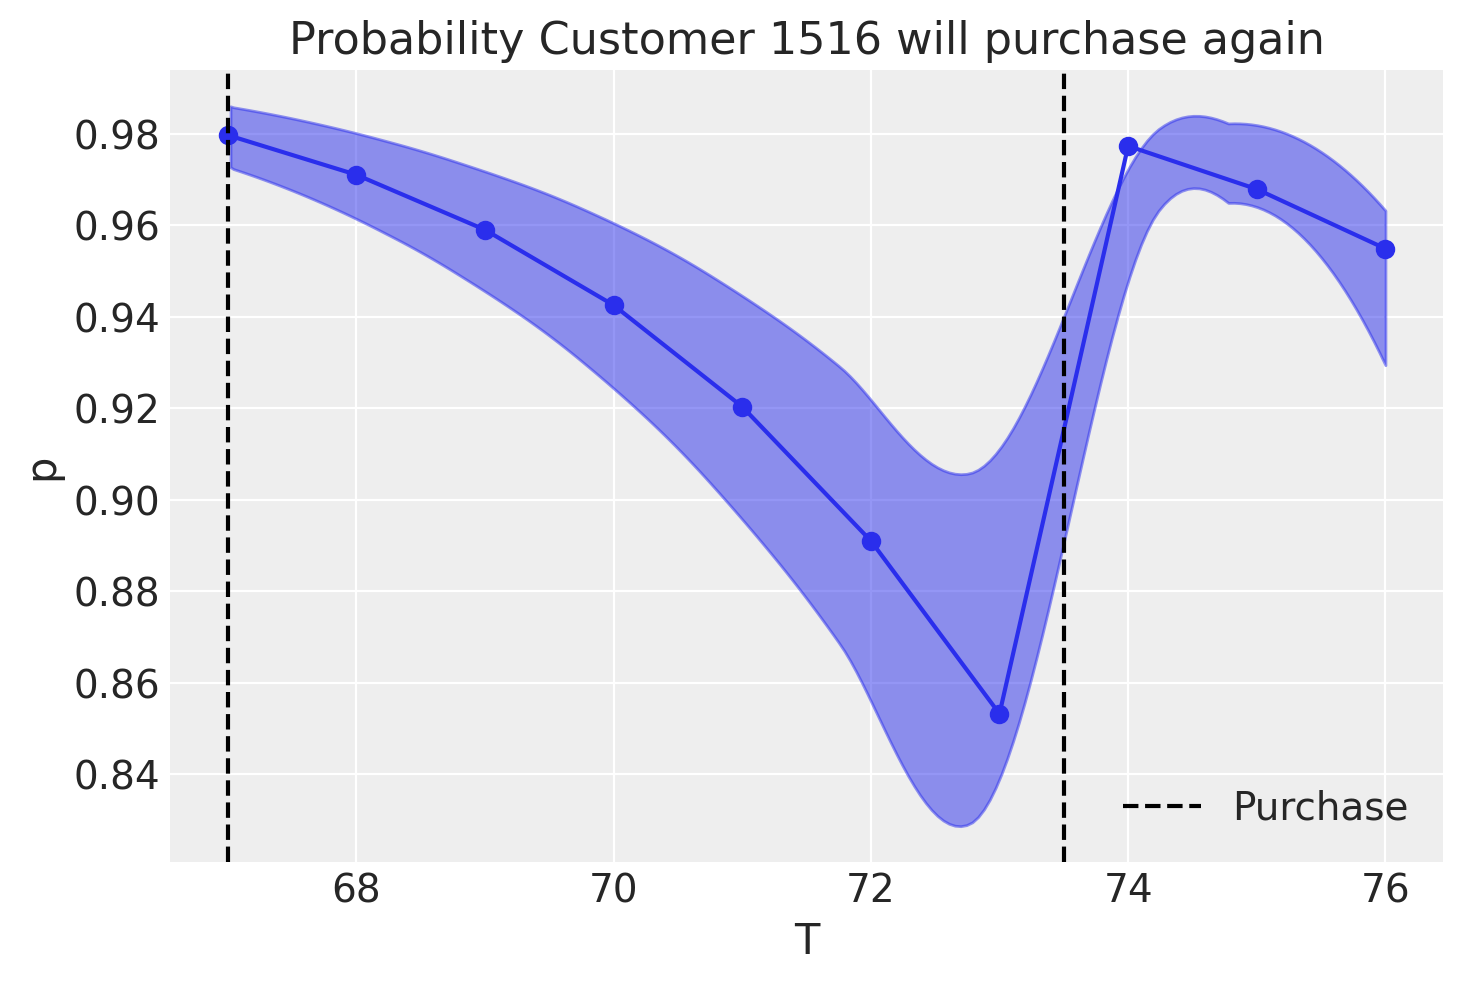

In [52]:
az.plot_hdi(customer_1516_history["T"], p_alive, color="C0")
plt.plot(customer_1516_history["T"], p_alive.mean(("draw", "chain")), marker="o")
plt.axvline(
    customer_1516_history["recency"].iloc[0], c="black", ls="--", label="Purchase"
)
plt.axvline(customer_1516_history["recency"].iloc[-1], c="black", ls="--")

plt.title("Probability Customer 1516 will purchase again")
plt.xlabel("T")
plt.ylabel("p")
plt.legend();

In [54]:
nonzero_data = rfm_data.query("frequency>0")
nonzero_data[["monetary_value", "frequency"]].corr()

,monetary_value,frequency
monetary_value,1.000000,0.052819
frequency,0.052819,1.000000


In [58]:
gg = clv.GammaGammaModel(nonzero_data)
gg.build_model()
gg

Gamma-Gamma Model (Mean Transactions)
         p ~ HalfFlat()
         q ~ HalfFlat()
         v ~ HalfFlat()
likelihood ~ Potential(f(q, p, v))

In [56]:
gg.fit(method="map")
gg.fit_summary()

Output()

p     4.785
q     3.882
v    22.653
Name: value, dtype: float64

In [60]:
gg.fit()
gg.fit_summary()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p, q, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 30 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,4.867,0.780,3.461,6.304,0.026,0.022,956.0,1028.0,1.0
q,3.902,0.271,3.402,4.417,0.009,0.006,971.0,1352.0,1.0
v,23.188,5.053,13.947,32.630,0.169,0.111,875.0,1015.0,1.0


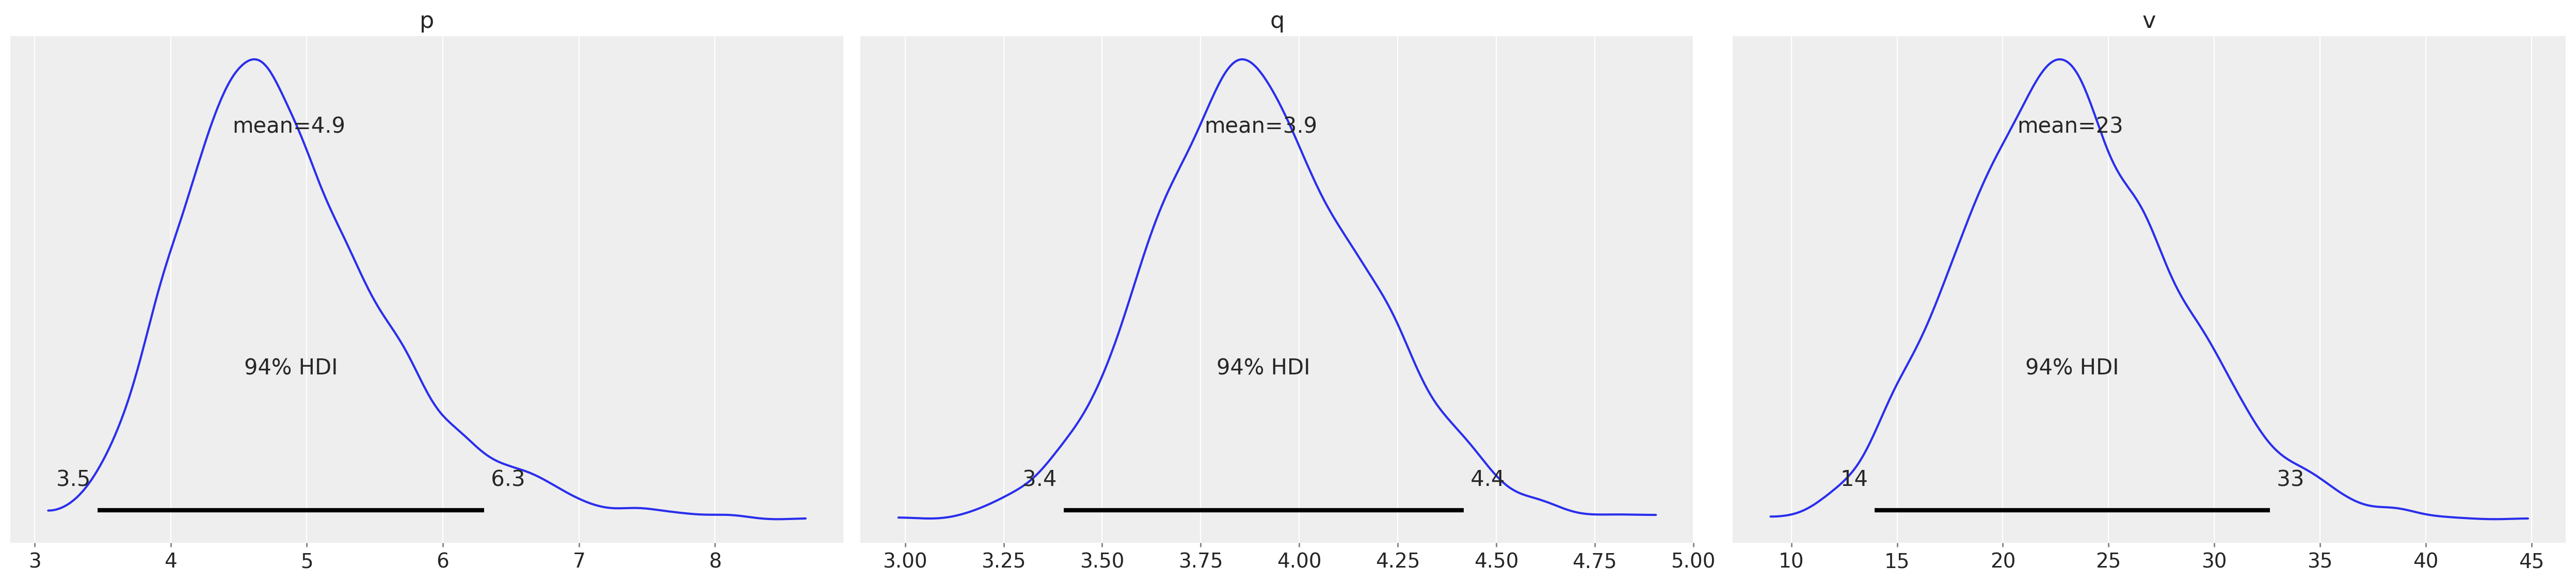

In [61]:
az.plot_posterior(gg.fit_result);

In [62]:
expected_spend = gg.expected_customer_spend(data=rfm_data)

az.summary(expected_spend.isel(customer_id=range(10)), kind="stats")

,mean,sd,hdi_3%,hdi_97%
x[1],26.078,0.431,25.304,26.903
x[2],21.522,1.328,18.802,23.761
x[3],37.667,0.886,36.049,39.338
x[4],37.667,0.886,36.049,39.338
x[5],37.667,0.886,36.049,39.338
x[6],74.868,0.354,74.237,75.555
x[7],21.522,1.328,18.802,23.761
x[8],30.862,0.603,29.776,31.996
x[9],36.435,0.148,36.160,36.713
x[10],37.667,0.886,36.049,39.338


Text(0.5, 0, 'Expected mean spend')

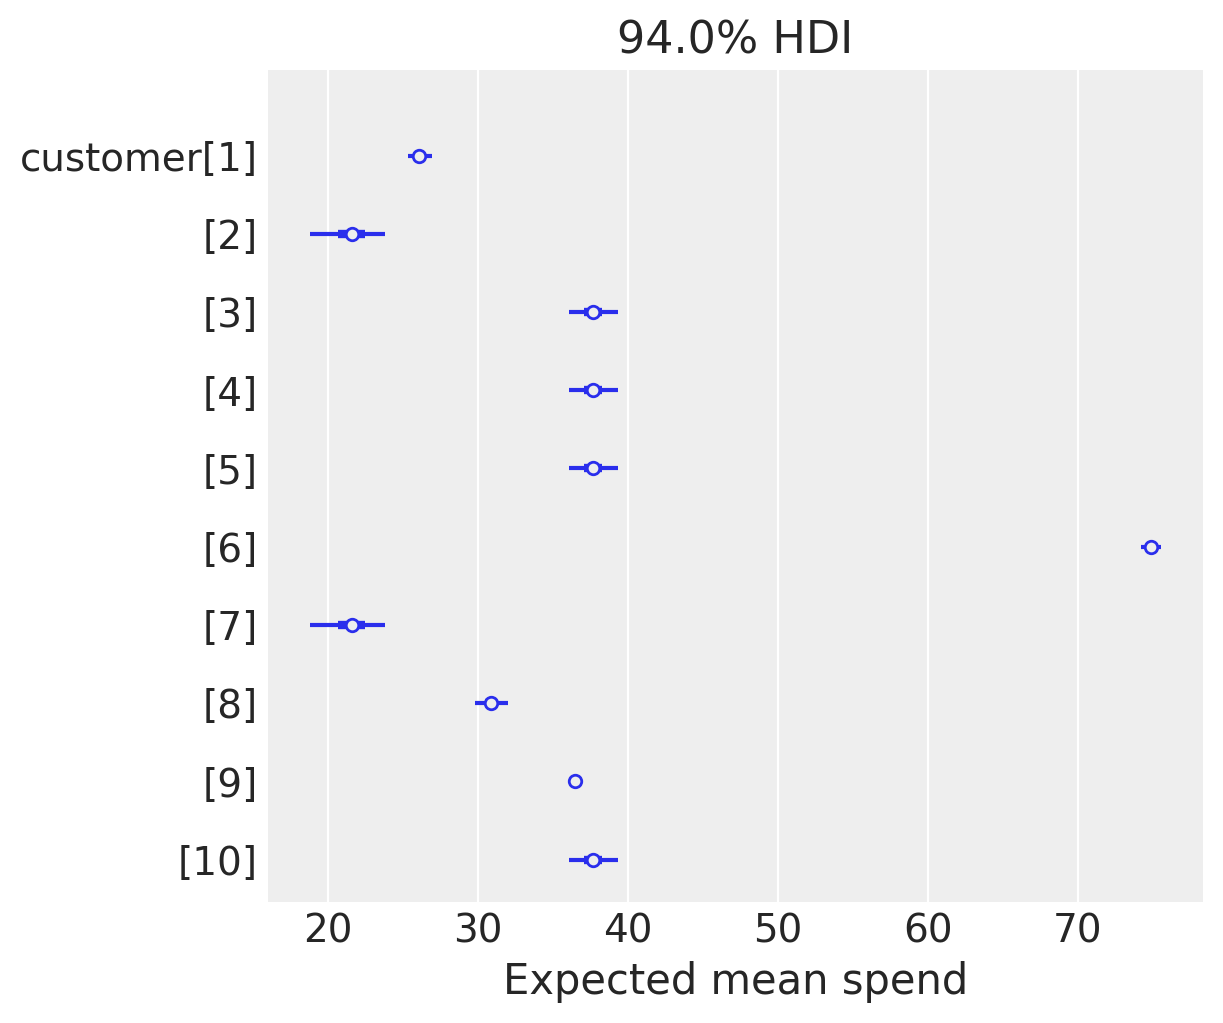

In [66]:
labeller = MapLabeller(var_name_map={"x":"customer"})
az.plot_forest(expected_spend.isel(customer_id=range(10)),combined=True,labeller=labeller)
plt.xlabel("Expected mean spend")

In [67]:
az.summary(expected_spend.mean("customer_id"),kind='stats')

,mean,sd,hdi_3%,hdi_97%
x,38.031,0.556,36.999,39.07


<AxesSubplot: title={'center': 'x'}>

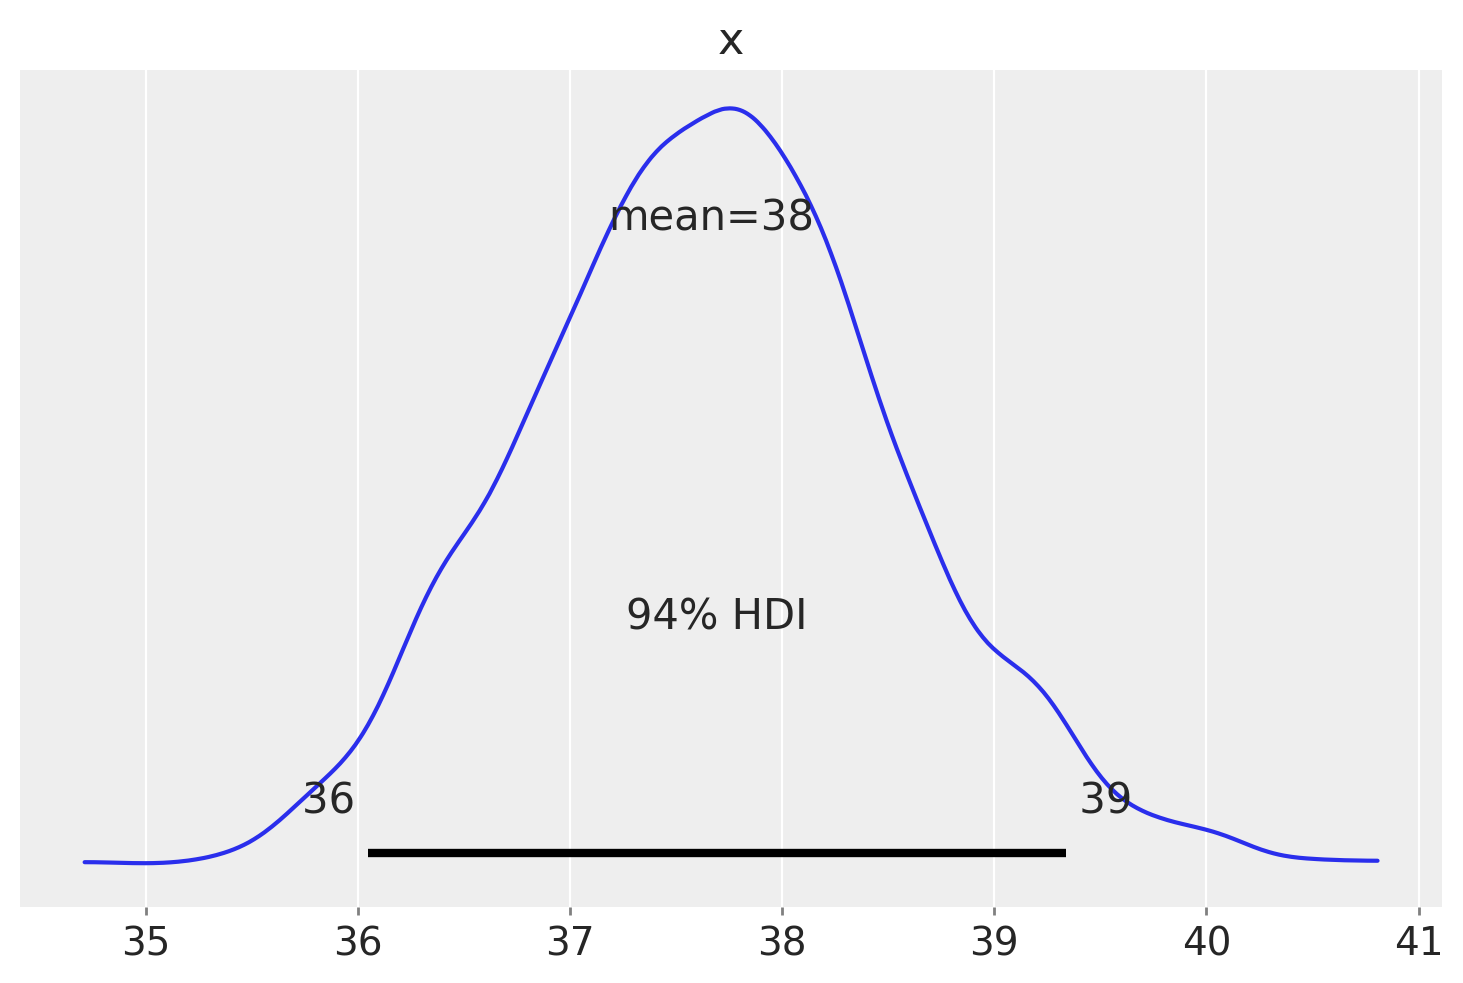

In [69]:
az.plot_posterior(gg.expected_new_customer_spend())

In [71]:
az.summary(gg.expected_new_customer_spend(),kind='stats')

,mean,sd,hdi_3%,hdi_97%
x,37.667,0.886,36.049,39.338


In [72]:
bgm.thin_fit_result(keep_every=2)

BG/NBD
            alpha ~ Weibull(2, 10)
      phi_dropout ~ Uniform(0, 1)
    kappa_dropout ~ Pareto(1, 1)
                r ~ Weibull(2, 1)
                a ~ Deterministic(f(kappa_dropout, phi_dropout))
                b ~ Deterministic(f(kappa_dropout, phi_dropout))
recency_frequency ~ BetaGeoNBD(a, b, r, alpha, <constant>)

In [73]:
clv_estimate = gg.expected_customer_lifetime_value(
    transaction_model=bgm,
    data=rfm_data,
    future_t=12,  # months
    discount_rate=0.01,  # monthly discount rate ~ 12.7% annually
    time_unit="W",  # original data is in weeks
)

In [74]:
az.summary(clv_estimate.isel(customer_id=range(10)),kind='stats')

,mean,sd,hdi_3%,hdi_97%
x[1],29.642,1.084,27.621,31.691
x[2],2.982,0.285,2.458,3.523
x[3],5.633,0.221,5.230,6.050
x[4],5.633,0.221,5.230,6.050
x[5],5.633,0.221,5.230,6.050
x[6],511.391,15.247,484.720,540.208
x[7],3.931,0.326,3.334,4.561
x[8],16.041,0.429,15.249,16.861
x[9],47.450,1.355,45.066,50.156
x[10],5.633,0.221,5.230,6.050


array([<AxesSubplot: title={'center': '94.0% HDI'}>], dtype=object)

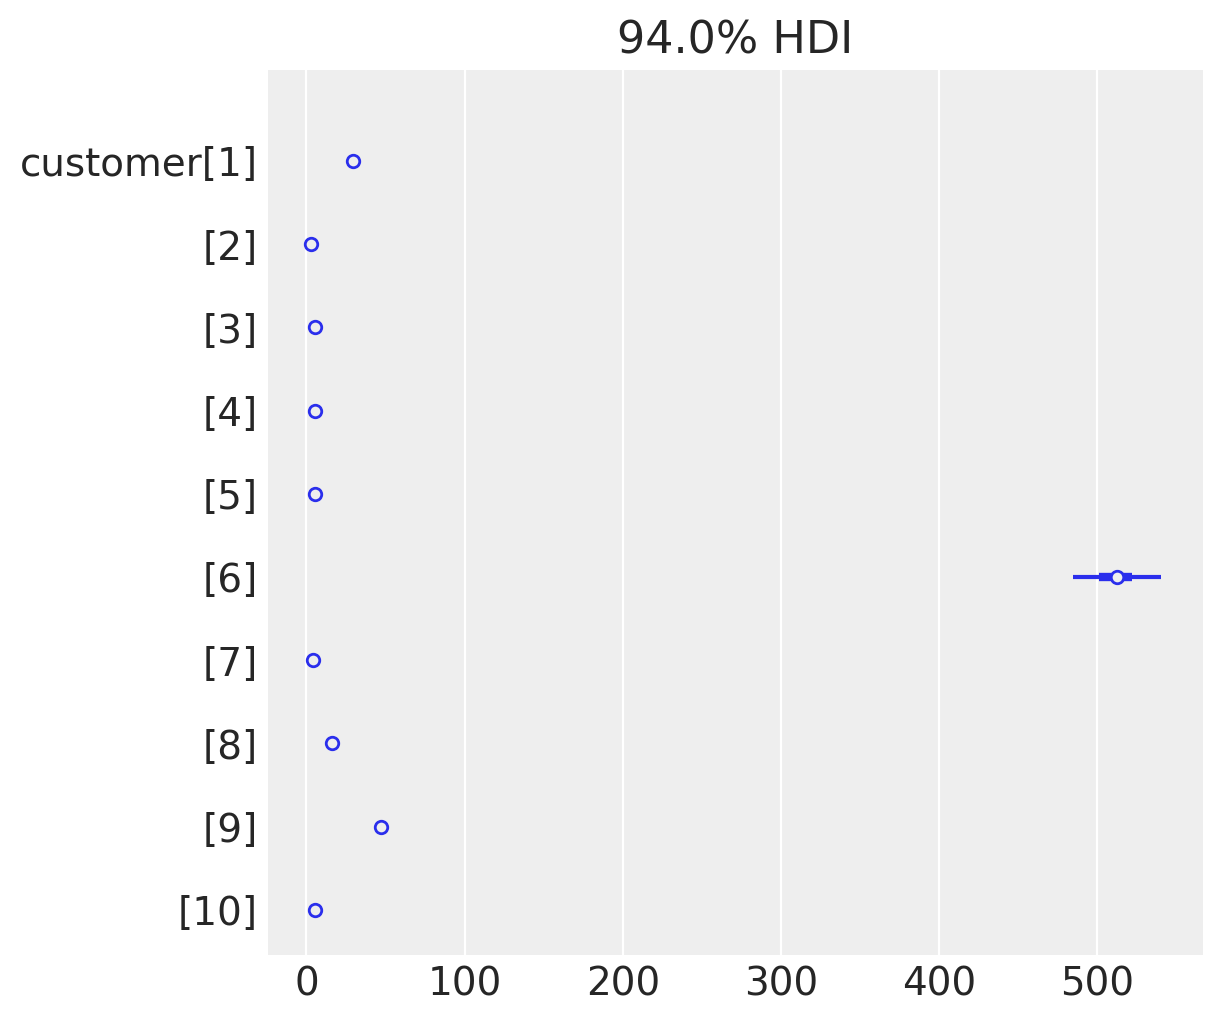

In [76]:
az.plot_forest(clv_estimate.isel(customer_id=range(10)),labeller=labeller,combined=True)